<a href="https://colab.research.google.com/github/coelhoana/Modelagem_Preditiva_de_Tumores/blob/main/ModelagemPreditivaTumores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('data.csv')
df.head()

Saving data.csv to data (5).csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
#Carregar WBCD
data = load_breast_cancer()

X = data.data          # 30 features
y = data.target        # 0 = maligno, 1 = benigno (padrão do sklearn)
feature_names = data.feature_names
target_names = data.target_names

print("Shape de X:", X.shape)
print("Classes:", target_names)
print("Distribuição de classes:", np.bincount(y))


Shape de X: (569, 30)
Classes: ['malignant' 'benign']
Distribuição de classes: [212 357]


In [ ]:
# 80% treino+val, 20% teste (estratificado)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Dentro dos 80%, separamos 20% para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape)
print("Validação:", X_val_scaled.shape)
print("Teste:", X_test_scaled.shape)

Treino: (364, 30)
Validação: (91, 30)
Teste: (114, 30)


In [ ]:
def build_mlp(
    input_dim,
    units1=32,
    units2=None,
    units3=None,
    dropout_rate=0.0,
    learning_rate=1e-3
):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # 1ª camada oculta
    model.add(layers.Dense(units1, activation="relu"))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # 2ª camada oculta (opcional)
    if units2 is not None:
        model.add(layers.Dense(units2, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # 3ª camada oculta (opcional)
    if units3 is not None:
        model.add(layers.Dense(units3, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Saída binária
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc_roc", curve="ROC"),
            keras.metrics.AUC(name="auc_pr", curve="PR"),
        ]
    )
    return model

In [ ]:
# Arquiteturas a serem comparadas
input_dim = X_train_scaled.shape[1]

model_configs = {
    "MLP_A_simples": {
        "units1": 16,
        "units2": None,
        "units3": None,
        "dropout_rate": 0.0,
        "learning_rate": 1e-3
    },
    "MLP_B_medio": {
        "units1": 32,
        "units2": 16,
        "units3": None,
        "dropout_rate": 0.2,
        "learning_rate": 1e-3
    },
    "MLP_C_profundo": {
        "units1": 64,
        "units2": 32,
        "units3": 16,
        "dropout_rate": 0.3,
        "learning_rate": 1e-3
    }
}

In [ ]:
# Treinamento e avaliação das redes neurais
histories = {}
results = []

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc_roc",
    patience=15,
    restore_best_weights=True
)

for name, cfg in model_configs.items():
    print(f"\nTreinando modelo: {name}")
    model = build_mlp(
        input_dim=input_dim,
        units1=cfg["units1"],
        units2=cfg["units2"],
        units3=cfg["units3"],
        dropout_rate=cfg["dropout_rate"],
        learning_rate=cfg["learning_rate"]
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0

    )

    histories[name] = history
    # Avaliação no conjunto de teste
    y_proba = model.predict(X_test_scaled).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({
        "modelo": name,
        "acuracia": acc,
        "precisao": prec,
        "sensibilidade": rec,
        "f1": f1,
        "auc_roc": auc
    })


    print(f"Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}")


Treinando modelo: MLP_A_simples
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Acurácia: 0.9649 | Precisão: 0.9722 | Recall: 0.9722 | F1: 0.9722 | AUC-ROC: 0.9931

Treinando modelo: MLP_B_medio
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Acurácia: 0.7632 | Precisão: 0.8689 | Recall: 0.7361 | F1: 0.7970 | AUC-ROC: 0.8644

Treinando modelo: MLP_C_profundo


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Acurácia: 0.8158 | Precisão: 0.9636 | Recall: 0.7361 | F1: 0.8346 | AUC-ROC: 0.9603


In [ ]:
# Tabela de comparação
results_df = pd.DataFrame(results)
results_df.sort_values(by="auc_roc", ascending=False, inplace=True)
results_df

,modelo,acuracia,precisao,sensibilidade,f1,auc_roc
0,MLP_A_simples,0.964912,0.972222,0.972222,0.972222,0.993056
2,MLP_C_profundo,0.815789,0.963636,0.736111,0.834646,0.960317
1,MLP_B_medio,0.763158,0.868852,0.736111,0.796992,0.864418


In [ ]:
# Escolha do melhor modelo
best_name = results_df.iloc[0]["modelo"]
print("Melhor modelo (por AUC-ROC):", best_name)

best_cfg = model_configs[best_name]
best_model = build_mlp(
    input_dim=input_dim,
    units1=best_cfg["units1"],
    units2=best_cfg["units2"],
    units3=best_cfg["units3"],
    dropout_rate=best_cfg["dropout_rate"],
    learning_rate=best_cfg["learning_rate"]
)

# Treina novamente juntando treino + validação para aproveitar mais dados
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled_final = scaler.transform(X_test)

history_best = best_model.fit(
    X_train_full_scaled, y_train_full,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Avaliação final
y_proba_best = best_model.predict(X_test_scaled_final).ravel()
y_pred_best = (y_proba_best >= 0.5).astype(int)

print("\nRelatório de classificação (melhor modelo):")
print(classification_report(y_test, y_pred_best, target_names=target_names))

Melhor modelo (por AUC-ROC): MLP_A_simples
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Relatório de classificação (melhor modelo):
              precision    recall  f1-score   support

   malignant       0.91      0.71      0.80        42
      benign       0.85      0.96      0.90        72

    accuracy                           0.87       114
   macro avg       0.88      0.84      0.85       114
weighted avg       0.87      0.87      0.86       114



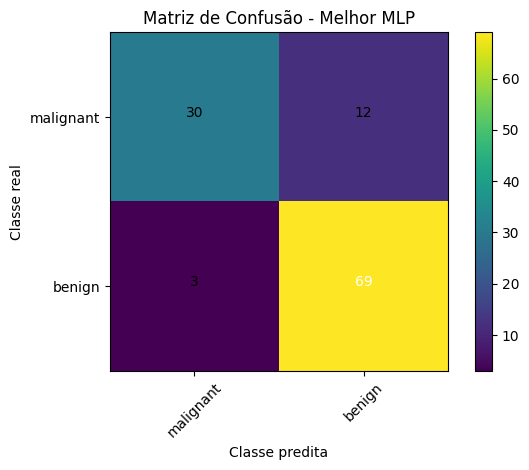

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure()
plt.imshow(cm_df, interpolation="nearest")
plt.title("Matriz de Confusão - Melhor MLP")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
plt.show()

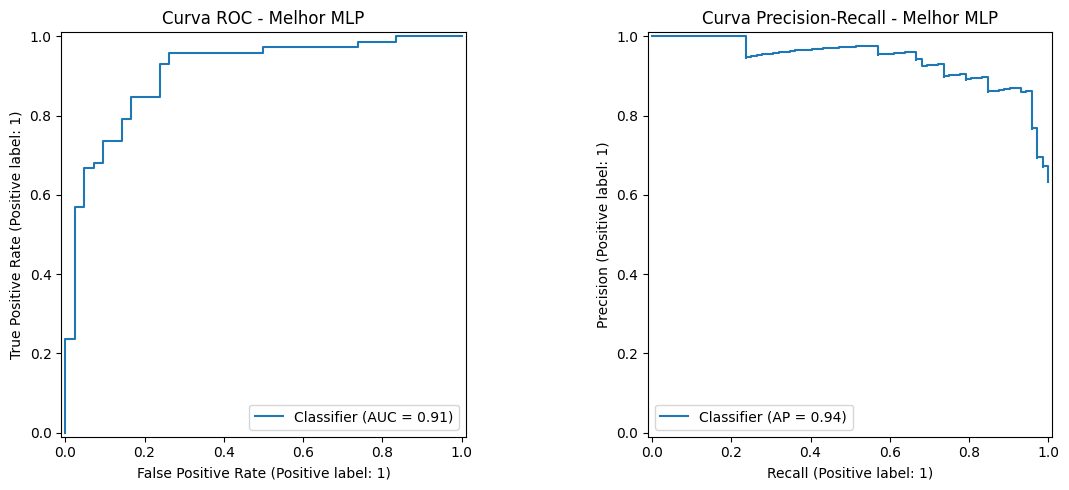

In [ ]:
# Curvas ROC e Precision Recall
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=ax[0])
ax[0].set_title("Curva ROC - Melhor MLP")

PrecisionRecallDisplay.from_predictions(y_test, y_proba_best, ax=ax[1])
ax[1].set_title("Curva Precision-Recall - Melhor MLP")

plt.tight_layout()
plt.show()